In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [3]:
X = np.array([40, 50, 60, 70, 80, 90, 100]).reshape(-1, 1)
y = np.array([78, 102, 118, 145, 158, 182, 205])

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## Bias Model (Underfitting)

In [10]:
model_low = LinearRegression()
model_low.fit(X_train, y_train)

X_line = np.linspace(40, 100, 200).reshape(-1, 1)
y_low = model_low.predict(X_line)

## Balanced Model (Good)

In [11]:
poly_2 = PolynomialFeatures(degree=2)
X_train_p2 = poly_2.fit_transform(X_train)
X_line_p2 = poly_2.transform(X_line)

model_mid = LinearRegression()
model_mid.fit(X_train_p2, y_train)

y_mid = model_mid.predict(X_line_p2)

## Variance Model (Overfitting)

In [12]:
poly_6 = PolynomialFeatures(degree=6)
X_train_p6 = poly_6.fit_transform(X_train)
X_line_p6 = poly_6.transform(X_line)

model_high = LinearRegression()
model_high.fit(X_train_p6, y_train)

y_high = model_high.predict(X_line_p6)

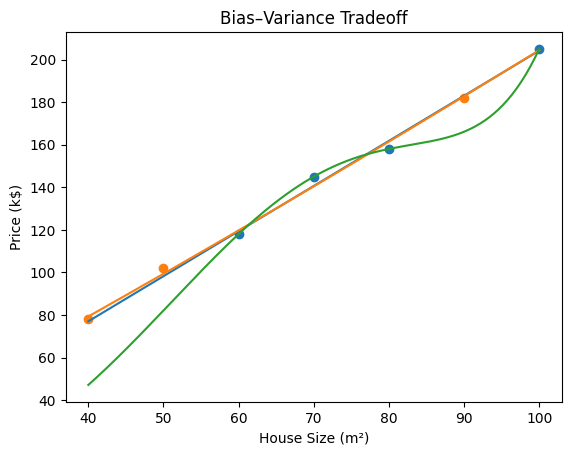

In [13]:
plt.scatter(X_train, y_train)
plt.scatter(X_test, y_test)

plt.plot(X_line, y_low)
plt.plot(X_line, y_mid)
plt.plot(X_line, y_high)

plt.title("Bias–Variance Tradeoff")
plt.xlabel("House Size (m²)")
plt.ylabel("Price (k$)")
plt.show()

In [17]:
print("Low bias / High bias MSE:",
      mean_squared_error(y_test, model_low.predict(X_test)))

print("Balanced MSE:",
      mean_squared_error(y_test,
          model_mid.predict(poly_2.transform(X_test))))

print("High variance MSE:",
      mean_squared_error(y_test,
          model_high.predict(poly_6.transform(X_test))))

Low bias / High bias MSE: 5.480000000000039
Balanced MSE: 3.1039669421498135
High variance MSE: 534.3785111216189
